In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [6]:
df = pd.read_csv("train.csv")
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load dataset
df = pd.read_csv("train.csv")

# Select useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical to numerical
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])        # male=1, female=0 (or vice versa)
df['Embarked'] = le.fit_transform(df['Embarked'])

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling (VERY important for KNN)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# KNN Model
knn = KNeighborsClassifier(n_neighbors=7)
knn.fit(X_train, y_train)

# Prediction
y_pred = knn.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Confusion Matrix:
 [[90 15]
 [19 55]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



In [15]:
# New passenger data
# Example:
# Pclass = 3, Sex = male, Age = 22, SibSp = 1, Parch = 0, Fare = 7.25, Embarked = S

new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['S']
})

# Encode categorical columns using same logic
new_passenger['Sex'] = le.fit_transform(new_passenger['Sex'])
new_passenger['Embarked'] = le.fit_transform(new_passenger['Embarked'])

# Scale using the SAME scaler used in training
new_passenger_scaled = scaler.transform(new_passenger)

# Predict
prediction = knn.predict(new_passenger_scaled)

if prediction[0] == 1:
    print("Prediction: Passenger will SURVIVE")
else:
    print("Prediction: Passenger will NOT survive")

Prediction: Passenger will SURVIVE


In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical columns
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Naive Bayes Model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Prediction
y_pred = nb.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.776536312849162

Confusion Matrix:
 [[82 23]
 [17 57]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.78      0.80       105
           1       0.71      0.77      0.74        74

    accuracy                           0.78       179
   macro avg       0.77      0.78      0.77       179
weighted avg       0.78      0.78      0.78       179



In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Select columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Create encoders
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

# Fit encoders on training data
df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Split
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

# Accuracy
print("Accuracy:", accuracy_score(y_test, nb.predict(X_test)))

# New Passenger Prediction

new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['S']
})

# Use SAME fitted encoders
new_passenger['Sex'] = le_sex.transform(new_passenger['Sex'])
new_passenger['Embarked'] = le_embarked.transform(new_passenger['Embarked'])

prediction = nb.predict(new_passenger)

if prediction[0] == 1:
    print("New Passenger: SURVIVED")
else:
    print("New Passenger: NOT SURVIVED")

Accuracy: 0.776536312849162
New Passenger: NOT SURVIVED


In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# 2. Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# 3. Encode categorical data
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# 4. Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# 5. Feature Scaling (important)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 6. Train Logistic Regression-
model = LogisticRegression()
model.fit(X_train, y_train)

# 7. Evaluation
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Prediction for NEW passenger
new_passenger = pd.DataFrame({
    'Pclass': [1],
    'Sex': ['female'],
    'Age': [22],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['Q']
})

# Encode using same encoders
new_passenger['Sex'] = le_sex.transform(new_passenger['Sex'])
new_passenger['Embarked'] = le_embarked.transform(new_passenger['Embarked'])

# Scale using same scaler
new_passenger_scaled = scaler.transform(new_passenger)

# Predict class
prediction = model.predict(new_passenger_scaled)

# Predict probability
probability = model.predict_proba(new_passenger_scaled)[0][1]

print("\nPredicted Survival Probability:", probability)

if prediction[0] == 1:
    print("New Passenger: SURVIVED")
else:
    print("New Passenger: NOT SURVIVED")

Accuracy: 0.8044692737430168

Confusion Matrix:
 [[90 15]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179


Predicted Survival Probability: 0.927555747071011
New Passenger: SURVIVED


In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select useful columns
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Encode categorical features
le_sex = LabelEncoder()
le_embarked = LabelEncoder()

df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

# Split features and target
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Scaling (important for SVM)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Train SVM model (RBF kernel)
svm_model = SVC(kernel='rbf')
svm_model.fit(X_train, y_train)

# Evaluate
y_pred = svm_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# New Passenger Prediction
new_passenger = pd.DataFrame({
    'Pclass': [3],
    'Sex': ['male'],
    'Age': [90],
    'SibSp': [1],
    'Parch': [0],
    'Fare': [7.25],
    'Embarked': ['S']
})

new_passenger['Sex'] = le_sex.transform(new_passenger['Sex'])
new_passenger['Embarked'] = le_embarked.transform(new_passenger['Embarked'])

new_passenger_scaled = scaler.transform(new_passenger)

prediction = svm_model.predict(new_passenger_scaled)

if prediction[0] == 1:
    print("\nNew Passenger: SURVIVED")
else:
    print("\nNew Passenger: NOT SURVIVED")

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[93 12]
 [21 53]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.89      0.85       105
           1       0.82      0.72      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.81       179
weighted avg       0.82      0.82      0.81       179


New Passenger: NOT SURVIVED


In [21]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score

df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked']]
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

le_sex = LabelEncoder()
le_embarked = LabelEncoder()
df['Sex'] = le_sex.fit_transform(df['Sex'])
df['Embarked'] = le_embarked.fit_transform(df['Embarked'])

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Models
models = {
    "Logistic": LogisticRegression(max_iter=1000),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "SVM": SVC(kernel='rbf', probability=True)
}

for name, model in models.items():
    print(f"\n {name}")
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='accuracy')
    print("CV Accuracy:", cv_scores.mean())
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:,1]
    
    # Metrics
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # ROC-AUC
    auc = roc_auc_score(y_test, y_prob)
    print("ROC-AUC:", auc)


 Logistic
CV Accuracy: 0.7934797596769428
Confusion Matrix:
 [[90 15]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.8818532818532818

 KNN
CV Accuracy: 0.8019403132079189
Confusion Matrix:
 [[90 15]
 [20 54]]

Classification Report:
               precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179

ROC-AUC: 0.8512226512226513

 SVM
CV Accuracy: 0.8215896779277061
Confusion Matrix:
 [[93 12]
 [21 53]]

Classi

Accuracy: 0.7988826815642458

Confusion Matrix:
 [[96  9]
 [27 47]]


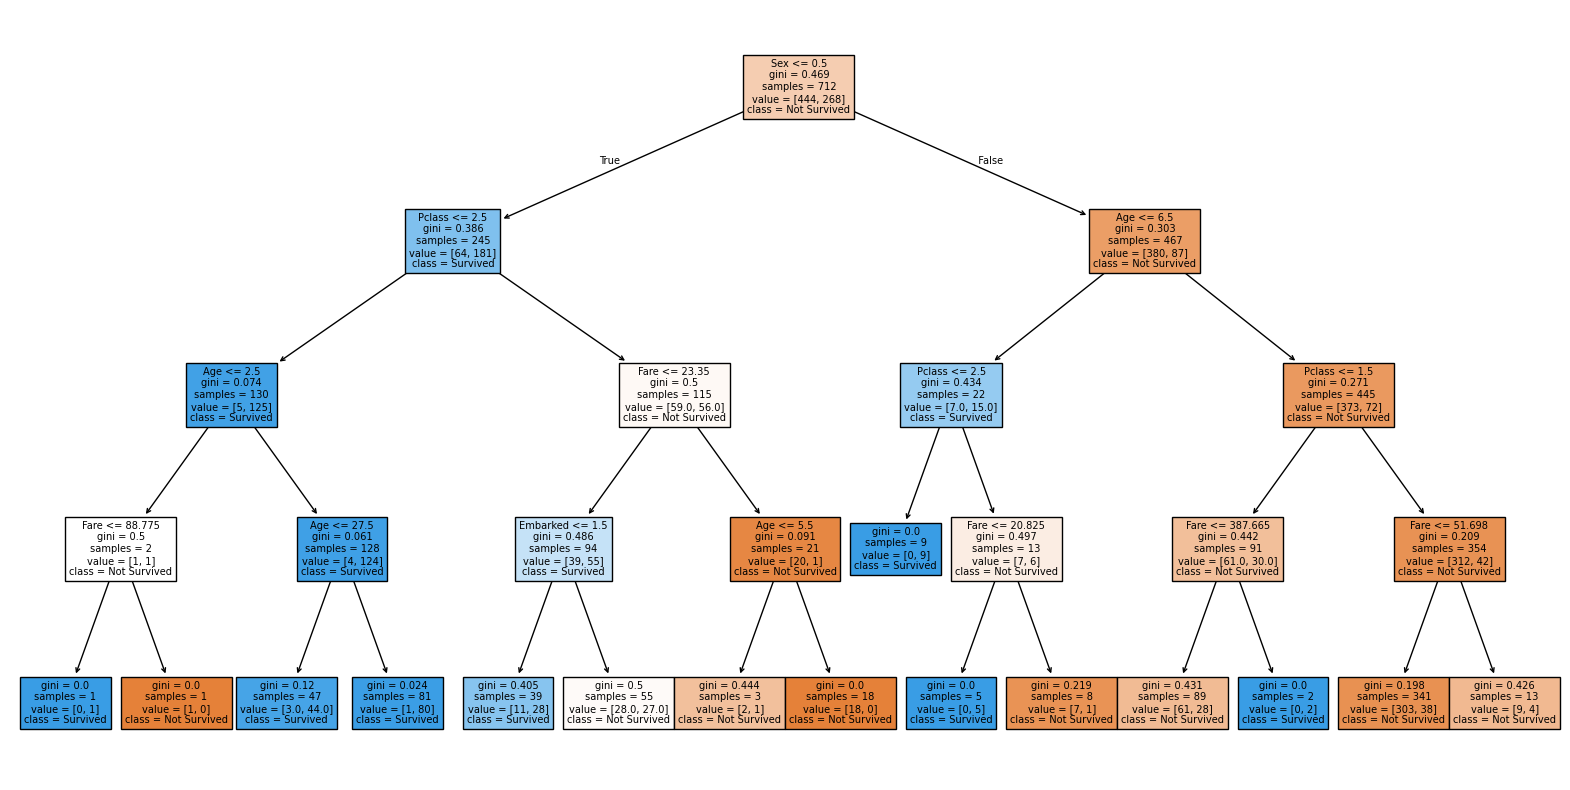

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt

# Select useful columns
data = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

# Handle missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Encode categorical columns
le_sex = LabelEncoder()
le_emb = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['Embarked'] = le_emb.fit_transform(data['Embarked'])

# Split features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Build Decision Tree (CART)
model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=4,
    random_state=42
)

model.fit(X_train, y_train)

# Prediction
y_pred = model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

# Visualize Tree
plt.figure(figsize=(20,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True
)
plt.show()

MAE: 0.7413793103448278
MSE: 0.7996432818073731
RMSE: 0.8942277572337894
R2 Score: 0.9111507464658475


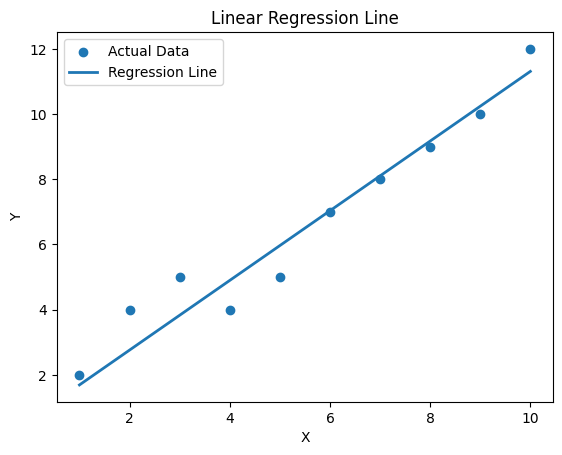

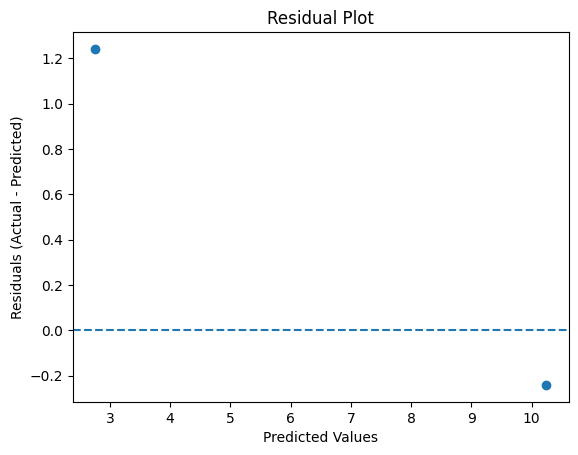

In [5]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Example dataset (you can replace this with your CSV file)
data = pd.DataFrame({
    "X": [1,2,3,4,5,6,7,8,9,10],
    "Y": [2,4,5,4,5,7,8,9,10,12]
})

X = data[['X']]
y = data['Y']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
model = LinearRegression()
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

# Visualization

# 1. Regression Line
plt.scatter(X, y, label="Actual Data")
plt.plot(X, model.predict(X), linewidth=2, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.title("Linear Regression Line")
plt.legend()
plt.show()

# 2. Residual Plot
residuals = y_test - y_pred

plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot")
plt.show()

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Select useful columns
data = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

# Handle missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Encode categorical columns
le_sex = LabelEncoder()
le_emb = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['Embarked'] = le_emb.fit_transform(data['Embarked'])

# Split features and target
X = data.drop('Survived', axis=1)
y = data['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Build Gradient Boosting Model
gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb_model.fit(X_train, y_train)

# Prediction
y_pred = gb_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.8156424581005587

Confusion Matrix:
 [[94 11]
 [22 52]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.90      0.85       105
           1       0.83      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.82      0.80      0.80       179
weighted avg       0.82      0.82      0.81       179



In [3]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

# Select useful columns
data = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]

# Handle missing values
data['Age'].fillna(data['Age'].median(), inplace=True)
data['Embarked'].fillna(data['Embarked'].mode()[0], inplace=True)

# Encode categorical features
le_sex = LabelEncoder()
le_emb = LabelEncoder()

data['Sex'] = le_sex.fit_transform(data['Sex'])
data['Embarked'] = le_emb.fit_transform(data['Embarked'])

# Split X and y
X = data.drop('Survived', axis=1)
y = data['Survived']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Base learner (Decision Stump)
base_model = DecisionTreeClassifier(max_depth=1)

# AdaBoost Model
ada_model = AdaBoostClassifier(
    estimator=base_model,
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

# Train
ada_model.fit(X_train, y_train)

# Predict
y_pred = ada_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7821229050279329

Confusion Matrix:
 [[88 17]
 [22 52]]


In [4]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Load dataset
df = pd.read_csv("train.csv")

# Select features
data = df[['Fare', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch']]

# Handle missing Age
data['Age'].fillna(data['Age'].median(), inplace=True)

# Encode categorical variable
le_sex = LabelEncoder()
data['Sex'] = le_sex.fit_transform(data['Sex'])

# Split X and y
X = data.drop('Fare', axis=1)
y = data['Fare']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

# Predictions
y_pred = lr_model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 19.675356018353344
MSE: 935.6645624776772
RMSE: 30.588634531107747
R2 Score: 0.39534273434575695


In [6]:
import mysql.connector
import pandas as pd

# Connect to MySQL
conn = mysql.connector.connect(
    host="localhost",
    user="root",
    password="12345@",
    database="company_db"
)

print("MySQL connected successfully")

MySQL connected successfully


In [12]:
query = "SELECT * FROM employees"

df = pd.read_sql(query, conn)

df.head()

,e_id,e_name,email,salary,d_id
0,101,Tanya,tanya@eg.com,60000.0,1.0
1,102,R,r@eg.com,40000.0,2.0
2,103,S,s@eg.com,30000.0,3.0
3,104,J,j@eg.com,60000.0,4.0
4,105,K,k@eg.com,45000.0,2.0


In [14]:
df = df.drop(columns=['e_id', 'e_name', 'email'])
df

,salary,d_id
0,60000.0,1.0
1,40000.0,2.0
2,30000.0,3.0
3,60000.0,4.0
4,45000.0,2.0
5,NaN,NaN


In [15]:
df.isnull().sum()

salary    1
d_id      1
dtype: int64

In [16]:
df = df.drop(index=5) # Drops the row with index label 5

In [17]:
df

,salary,d_id
0,60000.0,1.0
1,40000.0,2.0
2,30000.0,3.0
3,60000.0,4.0
4,45000.0,2.0


In [18]:
X = df[['d_id']]   # Feature
y = df['salary']   # Target

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [28]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 9500.0
MSE: 90250000.0
RMSE: 9500.0
R2 Score: nan


In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 9500.0
MSE: 90250000.0
RMSE: 9500.0
R2 Score: nan


In [30]:
new_employee = pd.DataFrame({'d_id': [2]})

predicted_salary = model.predict(new_employee)

print("Predicted Salary:", predicted_salary[0])

Predicted Salary: 49500.0


In [31]:
import joblib

joblib.dump(model, "employee_salary_model.pkl")
print("Model saved successfully")

Model saved successfully


In [32]:
loaded_model = joblib.load("employee_salary_model.pkl")

In [33]:
loaded_model.predict([[2]])

array([49500.])

In [11]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso, Ridge
X = np.array([[1,2],[2,3],[3,4],[4,5],[5,6],[6,7]])
y = np.array([3,5,7,9,11,13])
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
print("Linear Regression MSE:", mean_squared_error(y_test, y_pred_lr))


lasso = Lasso(alpha=0.1)
lasso.fit(X_train, y_train)

y_pred_lasso = lasso.predict(X_test)
print("Lasso MSE:", mean_squared_error(y_test, y_pred_lasso))
print("Lasso Coefficients:", lasso.coef_)


ridge = Ridge(alpha=0.1)
ridge.fit(X_train, y_train)

y_pred_ridge = ridge.predict(X_test)
print("Ridge MSE:", mean_squared_error(y_test, y_pred_ridge))
print("Ridge Coefficients:", ridge.coef_)

Linear Regression MSE: 5.127595883936577e-30
Lasso MSE: 0.059199999999999676
Lasso Coefficients: [1.92000000e+00 1.22124533e-16]
Ridge MSE: 0.0036270953828054777
Ridge Coefficients: [0.99009901 0.99009901]


In [16]:
from sklearn.model_selection import GridSearchCV
from xgboost import XGBClassifier

# Define Parameter Grid
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.1],
    'subsample': [0.8, 1],
    'colsample_bytree': [0.8, 1]
}

# Apply GridSearchCV
xgb = XGBClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='accuracy',
    cv=5,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

# Best Parameters
print("Best Parameters:", grid_search.best_params_)

# Train Final Model
best_model = grid_search.best_estimator_

y_pred_best = best_model.predict(X_test)

print("Tuned Accuracy:", accuracy_score(y_test, y_pred_best))

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Tuned Accuracy: 0.8100558659217877


In [17]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler

# Step 2: Create a sample dataset
# Salary has large values, Age has small values (scaling needed)
data = {
    'Age': [22, 25, 30, 35, 40, 45],
    'Salary': [25000, 30000, 50000, 80000, 120000, 200000]
}

df = pd.DataFrame(data)
print("Original Dataset:\n", df)

# Step 3: Apply MinMaxScaler
# Scales values between 0 and 1
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df),
    columns=df.columns
)

print("\nMinMax Scaled Data:\n", df_minmax)

# Step 4: Apply StandardScaler
# Converts data to mean = 0 and standard deviation = 1
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df),
    columns=df.columns
)

print("\nStandard Scaled Data:\n", df_standard)

# Step 5: Apply MaxAbsScaler
# Scales data between -1 and 1 based on max absolute value
maxabs_scaler = MaxAbsScaler()
df_maxabs = pd.DataFrame(
    maxabs_scaler.fit_transform(df),
    columns=df.columns
)

print("\nMaxAbs Scaled Data:\n", df_maxabs)

# Step 6: Apply RobustScaler
# Uses median and IQR, best when outliers exist
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df),
    columns=df.columns
)

print("\nRobust Scaled Data:\n", df_robust)

Original Dataset:
    Age  Salary
0   22   25000
1   25   30000
2   30   50000
3   35   80000
4   40  120000
5   45  200000

MinMax Scaled Data:
         Age    Salary
0  0.000000  0.000000
1  0.130435  0.028571
2  0.347826  0.142857
3  0.565217  0.314286
4  0.782609  0.542857
5  1.000000  1.000000

Standard Scaled Data:
         Age    Salary
0 -1.342276 -0.970058
1 -0.970569 -0.888081
2 -0.351057 -0.560174
3  0.268455 -0.068314
4  0.887967  0.587500
5  1.507480  1.899127

MaxAbs Scaled Data:
         Age  Salary
0  0.488889   0.125
1  0.555556   0.150
2  0.666667   0.250
3  0.777778   0.400
4  0.888889   0.600
5  1.000000   1.000

Robust Scaled Data:
     Age    Salary
0 -0.84 -0.533333
1 -0.60 -0.466667
2 -0.20 -0.200000
3  0.20  0.200000
4  0.60  0.733333
5  1.00  1.800000


In [7]:
# Step 1: Import required libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler, StandardScaler, MaxAbsScaler, RobustScaler
from sklearn.model_selection import train_test_split

# Step 2: Load Titanic dataset
df = pd.read_csv("train.csv")

print("Dataset Shape:", df.shape)
print(df.head())

# Step 3: Basic preprocessing

# Drop unnecessary columns (do not help in prediction)
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

# Handle missing values
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

# Convert categorical features into numerical
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)

# Step 4: Separate features and target
X = df.drop('Survived', axis=1)   # Features
y = df['Survived']                # Target

# Step 5: Train-Test Split
# IMPORTANT: Split before scaling to avoid data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 6: Select numerical columns only
num_features = ['Age', 'Fare', 'SibSp', 'Parch']

# Step 7: MinMaxScaler
minmax_scaler = MinMaxScaler()

X_train_minmax = X_train.copy()
X_test_minmax = X_test.copy()

X_train_minmax[num_features] = minmax_scaler.fit_transform(X_train[num_features])
X_test_minmax[num_features] = minmax_scaler.transform(X_test[num_features])

print("\nMinMaxScaler applied successfully")

# Step 8: StandardScaler
standard_scaler = StandardScaler()

X_train_standard = X_train.copy()
X_test_standard = X_test.copy()

X_train_standard[num_features] = standard_scaler.fit_transform(X_train[num_features])
X_test_standard[num_features] = standard_scaler.transform(X_test[num_features])

print("StandardScaler applied successfully")

# Step 9: MaxAbsScaler
maxabs_scaler = MaxAbsScaler()

X_train_maxabs = X_train.copy()
X_test_maxabs = X_test.copy()

X_train_maxabs[num_features] = maxabs_scaler.fit_transform(X_train[num_features])
X_test_maxabs[num_features] = maxabs_scaler.transform(X_test[num_features])

print("MaxAbsScaler applied successfully")

# Step 10: RobustScaler
robust_scaler = RobustScaler()

X_train_robust = X_train.copy()
X_test_robust = X_test.copy()

X_train_robust[num_features] = robust_scaler.fit_transform(X_train[num_features])
X_test_robust[num_features] = robust_scaler.transform(X_test[num_features])

print("RobustScaler applied successfully")

# Step 11: View scaled output
print("\nOriginal Numerical Features:\n", X_train[num_features].head())
print("\nStandard Scaled Features:\n", X_train_standard[num_features].head())
print("\nminmax Features:\n", X_train_minmax[num_features].head())
print("\nrobust Features:\n", X_train_robust[num_features].head())
print("\nStandard Scaled Features:\n", X_train_maxabs[num_features].head())

Dataset Shape: (891, 12)
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Cabin Embarked  
0      0         A/5 21171   7.2500   NaN        S  
1      0          PC 17599  71.2833   C85        C  
2      0  STON/O2. 3101282   7.9250   NaN        S  
3      0            113803  53.1000  C123        S  
4      0            373450   8

In [8]:
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.model_selection import train_test_split

df = pd.read_csv("train.csv")

df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True)

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# LABEL ENCODING (Ordinal Example)
label_encoder = LabelEncoder()

X_train['Pclass'] = label_encoder.fit_transform(X_train['Pclass'])
X_test['Pclass'] = label_encoder.transform(X_test['Pclass'])

# ONE HOT ENCODING (Nominal Example)
# Sex and Embarked are nominal features
X_train = pd.get_dummies(
    X_train,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

X_test = pd.get_dummies(
    X_test,
    columns=['Sex', 'Embarked'],
    drop_first=True
)

# Align train and test columns
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

print("One Hot Encoding applied successfully")

# TARGET ENCODING (Manual Implementation)
# Encode 'Sex' using mean survival rate

target_mean = X_train.join(y_train).groupby('Sex_male')['Survived'].mean()

X_train['Sex_Target_Encoded'] = X_train['Sex_male'].map(target_mean)
X_test['Sex_Target_Encoded'] = X_test['Sex_male'].map(target_mean)

print("Target Encoding applied successfully")

# Final encoded data
print("\nEncoded Training Data:\n", X_train.head())

One Hot Encoding applied successfully
Target Encoding applied successfully

Encoded Training Data:
      Pclass   Age  SibSp  Parch     Fare  Sex_male  Embarked_Q  Embarked_S  \
331       0  45.5      0      0  28.5000      True       False        True   
733       1  23.0      0      0  13.0000      True       False        True   
382       2  32.0      0      0   7.9250      True       False        True   
704       2  26.0      1      0   7.8542      True       False        True   
813       2   6.0      4      2  31.2750     False       False        True   

     Sex_Target_Encoded  
331            0.186296  
733            0.186296  
382            0.186296  
704            0.186296  
813            0.738776  


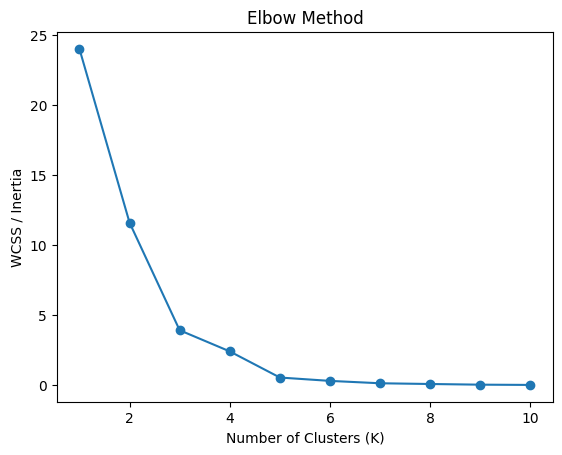

    Annual_Income  Spending_Score  Cluster
0              15              39        0
1              16              81        2
2              17               6        0
3              18              77        2
4              20              40        0
5              60              50        1
6              62              55        1
7              65              52        1
8              70              60        1
9              75              65        1
10             80              70        1
11             85              75        1


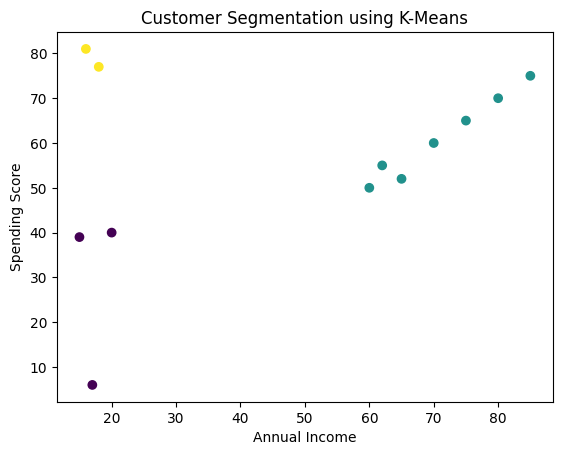

In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Create a sample dataset
data = {
    'Annual_Income': [15, 16, 17, 18, 20, 60, 62, 65, 70, 75, 80, 85],
    'Spending_Score': [39, 81, 6, 77, 40, 50, 55, 52, 60, 65, 70, 75]
}

df = pd.DataFrame(data)

# Feature Scaling (IMPORTANT)=
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df)

# Elbow Method to find K
wcss = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)  # inertia = WCSS

# Plot Elbow Curve
plt.figure()
plt.plot(range(1, 11), wcss, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('WCSS / Inertia')
plt.title('Elbow Method')
plt.show()

# Apply K-Means with optimal K
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

# Add cluster labels to dataset
df['Cluster'] = clusters

print(df)

# Visualize Clusters
plt.figure()
plt.scatter(df['Annual_Income'], df['Spending_Score'], c=df['Cluster'])
plt.xlabel('Annual Income')
plt.ylabel('Spending Score')
plt.title('Customer Segmentation using K-Means')
plt.show()

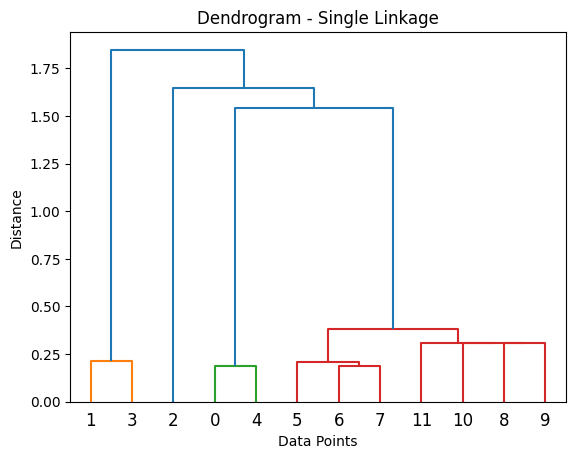

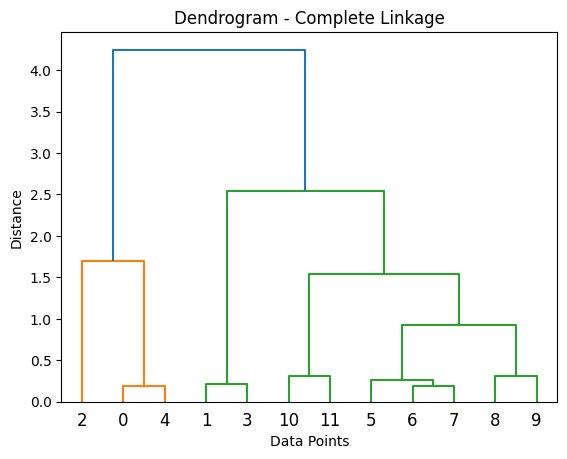

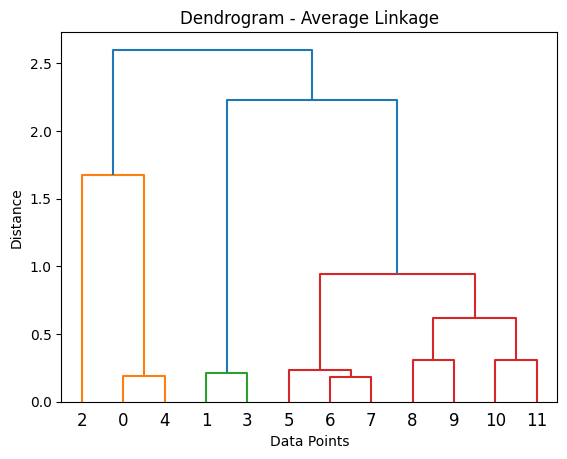

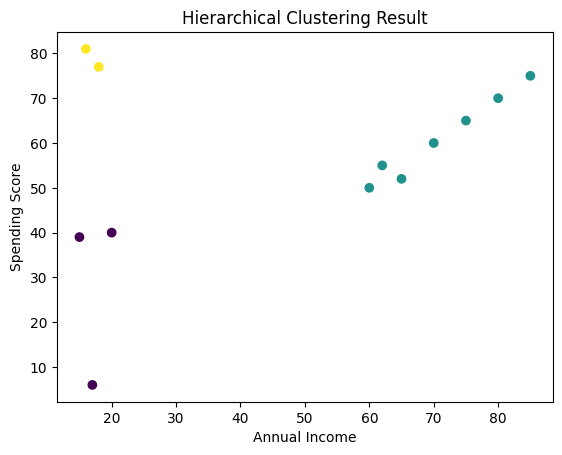

,Annual Income,Spending Score,Cluster
0,15,39,0
1,16,81,2
2,17,6,0
3,18,77,2
4,20,40,0
5,60,50,1
6,62,55,1
7,65,52,1
8,70,60,1
9,75,65,1


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage


# Sample dataset (can be replaced with real dataset)
X = np.array([
    [15, 39], [16, 81], [17, 6], [18, 77], [20, 40],
    [60, 50], [62, 55], [65, 52], [70, 60],
    [75, 65], [80, 70], [85, 75]
])


# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Creating linkage matrices for dendrograms
single_linkage = linkage(X_scaled, method='single')
complete_linkage = linkage(X_scaled, method='complete')
average_linkage = linkage(X_scaled, method='average')


# Dendrogram using single linkage
plt.figure()
dendrogram(single_linkage)
plt.title("Dendrogram - Single Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


# Dendrogram using complete linkage
plt.figure()
dendrogram(complete_linkage)
plt.title("Dendrogram - Complete Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


# Dendrogram using average linkage
plt.figure()
dendrogram(average_linkage)
plt.title("Dendrogram - Average Linkage")
plt.xlabel("Data Points")
plt.ylabel("Distance")
plt.show()


# Applying Agglomerative Clustering
model = AgglomerativeClustering(n_clusters=3, linkage='ward')
cluster_labels = model.fit_predict(X_scaled)


# Creating DataFrame for visualization
df = pd.DataFrame(X, columns=["Annual Income", "Spending Score"])
df["Cluster"] = cluster_labels


# Visualizing clustering result
plt.figure()
plt.scatter(df["Annual Income"], df["Spending Score"], c=df["Cluster"])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Hierarchical Clustering Result")
plt.show()


df

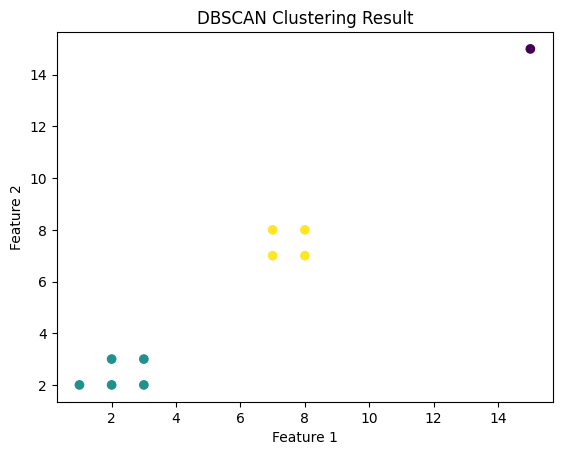

,Feature 1,Feature 2,Cluster
0,1,2,0
1,2,2,0
2,2,3,0
3,3,3,0
4,3,2,0
5,8,7,1
6,8,8,1
7,7,8,1
8,7,7,1
9,15,15,-1


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler


# Sample dataset with arbitrary shaped clusters
X = np.array([
    [1, 2], [2, 2], [2, 3], [3, 3], [3, 2],
    [8, 7], [8, 8], [7, 8], [7, 7],
    [15, 15]
])


# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# Applying DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=3)
labels = dbscan.fit_predict(X_scaled)


# Creating DataFrame for visualization
df = pd.DataFrame(X, columns=["Feature 1", "Feature 2"])
df["Cluster"] = labels


# Visualizing DBSCAN result
plt.figure()
plt.scatter(df["Feature 1"], df["Feature 2"], c=df["Cluster"])
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("DBSCAN Clustering Result")
plt.show()


df

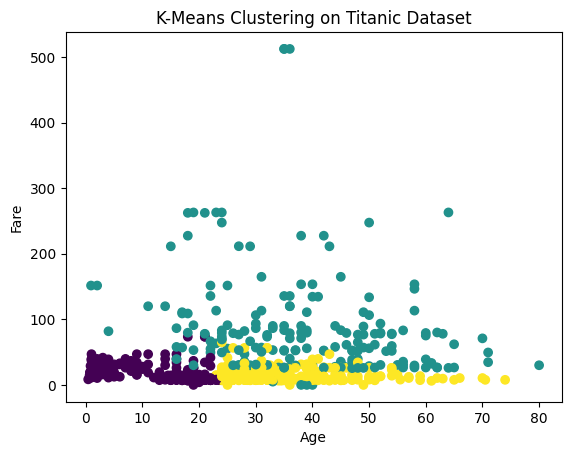

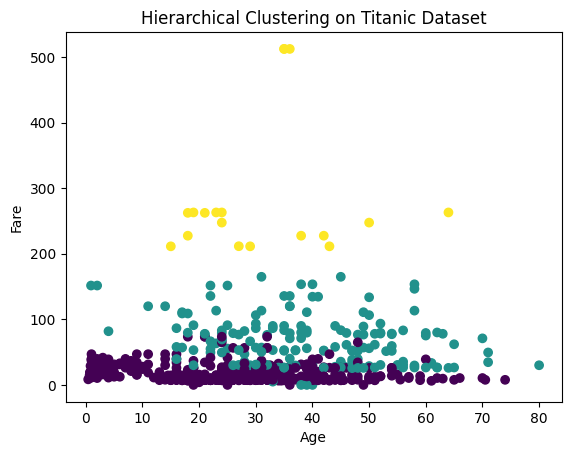

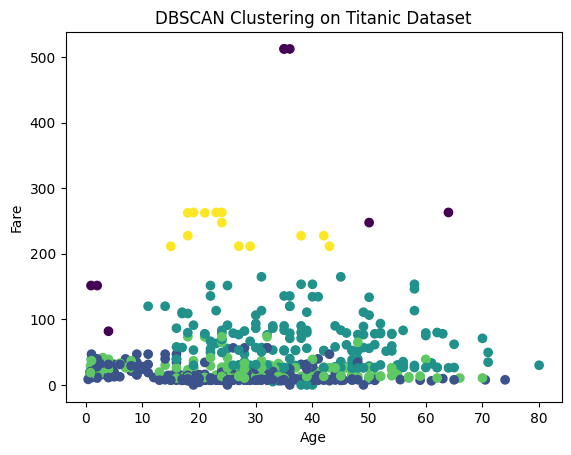

,Age,Fare,Pclass,KMeans_Cluster,Hierarchical_Cluster,DBSCAN_Cluster
0,22.0,7.2500,3,0,0,0
1,38.0,71.2833,1,1,1,1
2,26.0,7.9250,3,2,0,0
3,35.0,53.1000,1,1,1,1
4,35.0,8.0500,3,2,0,0


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN


# Loading Titanic dataset
df = pd.read_csv("train.csv")


# Selecting relevant features for clustering
data = df[["Age", "Fare", "Pclass"]]


# Handling missing values
data["Age"].fillna(data["Age"].median(), inplace=True)


# Feature scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(data)


# K-Means Clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df["KMeans_Cluster"] = kmeans.fit_predict(X_scaled)


# Hierarchical Clustering
hierarchical = AgglomerativeClustering(n_clusters=3, linkage="ward")
df["Hierarchical_Cluster"] = hierarchical.fit_predict(X_scaled)


# DBSCAN Clustering
dbscan = DBSCAN(eps=0.9, min_samples=5)
df["DBSCAN_Cluster"] = dbscan.fit_predict(X_scaled)


# Visualization: K-Means
plt.figure()
plt.scatter(df["Age"], df["Fare"], c=df["KMeans_Cluster"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("K-Means Clustering on Titanic Dataset")
plt.show()


# Visualization: Hierarchical
plt.figure()
plt.scatter(df["Age"], df["Fare"], c=df["Hierarchical_Cluster"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("Hierarchical Clustering on Titanic Dataset")
plt.show()


# Visualization: DBSCAN
plt.figure()
plt.scatter(df["Age"], df["Fare"], c=df["DBSCAN_Cluster"])
plt.xlabel("Age")
plt.ylabel("Fare")
plt.title("DBSCAN Clustering on Titanic Dataset")
plt.show()


df[["Age", "Fare", "Pclass", "KMeans_Cluster", "Hierarchical_Cluster", "DBSCAN_Cluster"]].head()